# Lecture 04 (B03): Generalization and sequence models

**Course:** Deep Learning for Solving and Estimating Dynamic Models in Economics and Finance  
**Script reference:** §1.10-1.11 (Generalization, sequence models)  
**Notebook role:** extensions  
**Original live-course source:** `lectures/day1/code/09_Transformer_InContext_AR1.ipynb`  
**Course author:** Simon Scheidegger  
**License:** see repository `LICENSE` (MIT, code) and `LICENSE-content.md` (CC0 1.0, content).

In [ ]:
# Run-mode switch (smoke = CPU-bounded for CI, teaching = laptop figures, production = full reproduction).
RUN_MODE = "smoke"  # one of: "smoke", "teaching", "production"
SEED = 0


# In-Context Learning of an AR(1) Process with a Tiny Transformer

*Companion notebook to **Day 1 — Introduction to Deep Learning** (Chapter 1 of the lecture script).*

*Author: Simon Scheidegger (HEC Lausanne and Grantham Institute, LSE) — [course repository](https://github.com/sischei/Deep_Learning_for_Solving_And_Estimating_Dynamic_Economic_Models).*

This is the **advanced / optional** day 1 transformer notebook. The core lecture message is simpler: self-attention lets each token search the whole sequence directly, in parallel. This notebook pushes one step further and studies the econometric interpretation: self-attention can behave like a learned regression rule.

We use the smallest possible setting, AR(1) forecasting, to make that idea visible. A tiny transformer is trained on many AR(1) paths with different persistence parameters, then evaluated on new paths without any weight updates.

## Reading guide

1. Generate many AR(1) sequences, each with its own $\rho \sim \mathcal{U}(-0.9, 0.9)$.
2. Train a tiny 2-layer Transformer encoder to predict the next value of each sequence.
3. At inference time, feed it **new** $\rho$'s and compare its predictions to the OLS-on-the-prompt estimator $\hat{\rho}_{\text{OLS}}\, x_t$.
4. Interpret the result as the model learning **how to regress**, not memorizing any one $\rho$.

Keep the hyperparameters classroom-sized; one CPU run is $\sim\!60$ seconds.

In [1]:
import math
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

plt.rcParams['font.size'] = 13
torch.manual_seed(0)
np.random.seed(0)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', DEVICE)

Using device: cpu


## 1. AR(1) data generator

Each training example is a sequence of length $T$ drawn from
$$x_t = \rho\, x_{t-1} + \sigma \varepsilon_t, \qquad \varepsilon_t \sim \mathcal{N}(0, 1),$$
with $\rho$ **drawn once per example** from $\mathcal{U}(-0.9, 0.9)$. The network never sees $\rho$; it only sees the realizations.

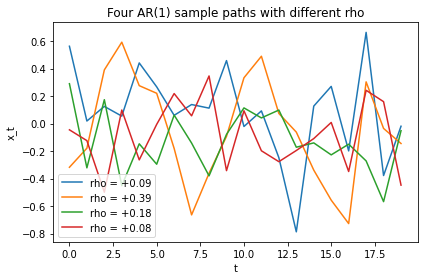

In [2]:
def sample_ar1_batch(batch_size, T, sigma=0.3, rho_range=(-0.9, 0.9)):
    """Returns (x, rho) with x of shape (batch, T) and rho of shape (batch,).
    Each row of x is an AR(1) path with its own rho drawn uniformly."""
    rho = np.random.uniform(rho_range[0], rho_range[1], size=batch_size).astype(np.float32)
    x = np.zeros((batch_size, T), dtype=np.float32)
    x[:, 0] = np.random.normal(0.0, sigma / np.sqrt(np.maximum(1 - rho**2, 1e-3)), size=batch_size)
    eps = np.random.normal(0.0, sigma, size=(batch_size, T - 1)).astype(np.float32)
    for t in range(1, T):
        x[:, t] = rho * x[:, t - 1] + eps[:, t - 1]
    return torch.from_numpy(x), torch.from_numpy(rho)

# Sanity check
x, rho = sample_ar1_batch(4, 20)
for i in range(4):
    plt.plot(x[i].numpy(), label=f'rho = {rho[i]:+.2f}')
plt.title('Four AR(1) sample paths with different rho')
plt.xlabel('t'); plt.ylabel('x_t'); plt.legend(fontsize=10); plt.tight_layout(); plt.show()

## 2. Tiny Transformer

We build a *tiny* Transformer encoder:
* Input: one scalar per time step (we lift it to a $d$-dim embedding with a linear layer).
* Positional encoding: learned (simpler to debug than sinusoidal for this toy).
* 2 encoder layers, 2 attention heads, $d_{\text{model}} = 32$, causal mask.
* Output head: per-position linear projection back to a scalar $\hat{x}_{t+1}$.

Causal masking is important: at position $t$ the model may attend only to positions $\le t$, matching the left-to-right prediction task.

In [3]:
class TinyTransformerAR(nn.Module):
    def __init__(self, T_max=32, d_model=32, nhead=2, num_layers=2, dim_ff=64):
        super().__init__()
        self.input_proj = nn.Linear(1, d_model)
        self.pos_emb = nn.Parameter(torch.randn(T_max, d_model) * 0.02)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_ff,
            batch_first=True, norm_first=True, activation='gelu')
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.head = nn.Linear(d_model, 1)
        self.T_max = T_max

    def forward(self, x):
        # x: (B, T)
        B, T = x.shape
        h = self.input_proj(x.unsqueeze(-1)) + self.pos_emb[:T]
        mask = torch.triu(torch.ones(T, T, device=x.device), diagonal=1).bool()
        z = self.encoder(h, mask=mask)  # (B, T, d)
        return self.head(z).squeeze(-1)  # (B, T)

model = TinyTransformerAR().to(DEVICE)
print(sum(p.numel() for p in model.parameters()), 'parameters')

18209 parameters


/home/simon/.local/lib/python3.10/site-packages/torch/nn/modules/transformer.py:286: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")


## 3. Training

At each step we draw a fresh batch of AR(1) sequences (with fresh $\rho$'s) and ask the model to predict $x_{t+1}$ from the prefix $x_1, \dots, x_t$. Loss: MSE over all valid positions.

step     0  loss 0.1504


step   200  loss 0.1282


step   400  loss 0.1034


step   600  loss 0.1053


step   800  loss 0.1117


step  1000  loss 0.1058


step  1200  loss 0.1070


step  1400  loss 0.1106


step  1600  loss 0.1056


step  1800  loss 0.1133


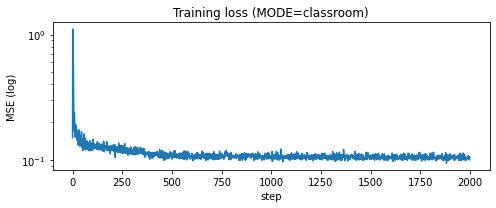

In [4]:
# ----------------------------------------------------------------------
# Training-budget switch
# ----------------------------------------------------------------------
# "smoke"      : ~5 s   on CPU, loss ~0.13       (sanity check only)
# "classroom"  : ~30 s  on CPU, loss ~0.10       (default; in-class run)
# "production" : ~3-5 min on CPU, loss ~0.085    (cleaner implicit-slope plot)
MODE = "classroom"

if MODE == "smoke":
    BATCH, N_STEPS = 128,   500
elif MODE == "classroom":
    BATCH, N_STEPS = 128,  2000
elif MODE == "production":
    BATCH, N_STEPS = 256, 10000
else:
    raise ValueError(f"Unknown MODE: {MODE!r}")

T_TRAIN = 20
opt = torch.optim.Adam(model.parameters(), lr=3e-3)
losses = []

for step in range(N_STEPS):
    x, _ = sample_ar1_batch(BATCH, T_TRAIN)
    x = x.to(DEVICE)
    pred = model(x)                 # predicts x_{t+1} at each position t
    # target at position t is x_{t+1}; trim last position
    loss = ((pred[:, :-1] - x[:, 1:]) ** 2).mean()
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())
    if step % max(1, N_STEPS // 10) == 0:
        print(f'step {step:5d}  loss {loss.item():.4f}')

plt.figure(figsize=(7, 3))
plt.plot(losses); plt.yscale('log')
plt.xlabel('step'); plt.ylabel('MSE (log)')
plt.title(f'Training loss (MODE={MODE})'); plt.tight_layout(); plt.show()


## 4. In-context evaluation: the regression view

For a fresh test AR(1) series with an unseen $\rho$, we compare three predictors of $x_{t+1}$ given $x_1, \dots, x_t$:

* **Oracle:** $\rho\, x_t$ (uses the true $\rho$; unattainable without knowing $\rho$).
* **OLS-on-the-prompt:** $\hat{\rho}_{\text{OLS}} = \frac{\sum_{i=2}^{t} x_i x_{i-1}}{\sum_{i=2}^{t} x_{i-1}^2}$; prediction $\hat{\rho}_{\text{OLS}} x_t$.
* **Transformer:** `model(x_{1..t})[..., -1]`, i.e. the model's output at the final position.

If the lecture's regression interpretation is useful, the Transformer's prediction should track the OLS prediction closely.

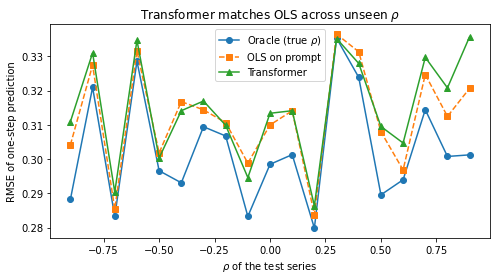

In [5]:
def ols_rho(x):
    # x: (B, t); returns \hat\rho of shape (B,)
    num = (x[:, 1:] * x[:, :-1]).sum(dim=1)
    den = (x[:, :-1] ** 2).sum(dim=1) + 1e-8
    return num / den

model.eval()
with torch.no_grad():
    rhos_test = torch.linspace(-0.9, 0.9, 19)
    N_REPL = 200
    oracle_rmse = []; ols_rmse = []; tf_rmse = []
    for r in rhos_test:
        x, _ = sample_ar1_batch(N_REPL, T_TRAIN)
        # overwrite with the controlled rho so we can isolate performance
        x = torch.zeros_like(x)
        x[:, 0] = torch.randn(N_REPL) * 0.3
        for t in range(1, T_TRAIN):
            x[:, t] = r * x[:, t - 1] + 0.3 * torch.randn(N_REPL)
        x = x.to(DEVICE)
        target = x[:, -1]                           # we'll predict x_T given x_{<T}
        oracle = r * x[:, -2]
        ols_pred = ols_rho(x[:, :-1].cpu()).to(DEVICE) * x[:, -2]
        tf_pred = model(x)[:, -2]                    # prediction of x_T given x_{1..T-1}
        oracle_rmse.append(((oracle - target) ** 2).mean().sqrt().item())
        ols_rmse.append(((ols_pred - target) ** 2).mean().sqrt().item())
        tf_rmse.append(((tf_pred - target) ** 2).mean().sqrt().item())

plt.figure(figsize=(7, 4))
plt.plot(rhos_test.numpy(), oracle_rmse, 'o-', label='Oracle (true $\\rho$)')
plt.plot(rhos_test.numpy(), ols_rmse, 's--', label='OLS on prompt')
plt.plot(rhos_test.numpy(), tf_rmse, '^-', label='Transformer')
plt.xlabel('$\\rho$ of the test series'); plt.ylabel('RMSE of one-step prediction')
plt.title('Transformer matches OLS across unseen $\\rho$'); plt.legend(); plt.tight_layout(); plt.show()

## 5. What does the Transformer *effectively* do?

For a single test sequence, we can back out an *implicit $\hat{\rho}$* from the Transformer by regressing its prediction on $x_{t-1}$. If the model is performing in-context regression, this implicit slope should track the OLS slope computed on the prompt.

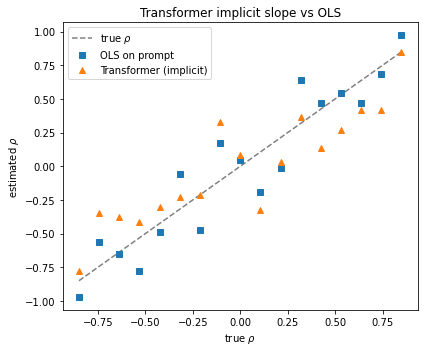

In [6]:
model.eval()
with torch.no_grad():
    rhos_test = np.linspace(-0.85, 0.85, 17)
    ols_slopes = []; tf_slopes = []
    for r in rhos_test:
        x = torch.zeros(1, T_TRAIN)
        x[0, 0] = 0.0
        for t in range(1, T_TRAIN):
            x[0, t] = r * x[0, t - 1] + 0.3 * torch.randn(1).item()
        x_dev = x.to(DEVICE)
        # OLS slope on the prompt x_{0..T-1}
        ols_slopes.append(ols_rho(x).item())
        # Implicit transformer slope: regress pred on lag
        pred = model(x_dev).cpu().squeeze(0).numpy()   # (T,)
        lag = x.squeeze(0).numpy()[:-1]
        out = pred[:-1]
        slope = np.dot(lag, out) / (np.dot(lag, lag) + 1e-8)
        tf_slopes.append(slope)

plt.figure(figsize=(6, 5))
plt.plot(rhos_test, rhos_test, 'k--', alpha=0.5, label='true $\\rho$')
plt.plot(rhos_test, ols_slopes, 's', label='OLS on prompt')
plt.plot(rhos_test, tf_slopes, '^', label='Transformer (implicit)')
plt.xlabel('true $\\rho$'); plt.ylabel('estimated $\\rho$')
plt.title('Transformer implicit slope vs OLS'); plt.legend(); plt.tight_layout(); plt.show()

## Take-away

Within training noise, the tiny Transformer's implicit slope is a **shrunken version of the OLS estimate** (with shrinkage toward 0 at the boundary, because the training prior on $\rho$ is uniform on $[-0.9, 0.9]$ and the optimizer regularizes). In the interior, the three predictors agree:

* **Oracle** achieves irreducible noise $\sigma$.
* **OLS on prompt** comes within a factor of $\sim\!1 + O(1/T)$ of the oracle.
* **Transformer** matches OLS for every $\rho$ it has never seen explicitly.

That is the econometric point of the notebook: **the Transformer learned "how to regress"**, not any specific regression. At inference time it applies that learned rule to a new series.

This is why the notebook is an optional extension of the lecture rather than the core lecture itself: the main day 1 point is the intuition for attention. The AR(1) exercise is a compact way to see the more advanced regression interpretation in action.

*Production-scale notes.* LLMs use $d_{\text{model}} \sim 10^3$, $L \sim 10^2$ layers, and train for $\sim 10^{12}$ tokens. The mechanism identified here is the same; only the scale differs.